In [27]:
from typing_extensions import TypedDict
from typing import Literal # define the constants
import random

class TypedDictState(TypedDict):
    name: str
    game: Literal['cricket', 'badminton']

In [28]:
def play_game(state: TypedDictState):
    print("-- play game node has been called --")
    return {"name": state['name']}

def cricket(state: TypedDictState):
    print("-- cricket node has been called --")
    return {"name": state['name'], "game": "cricket"}

def badminton(state: TypedDictState):
    print("-- badminton node has been called --")
    return {"name": state['name'],  "game": "badminton"}

def decide_play(state: TypedDictState) -> Literal['cricket', 'badminton']:
    if random.random()<0.5:
        return 'cricket'
    else:
        return 'badminton'
    

In [29]:
import random
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

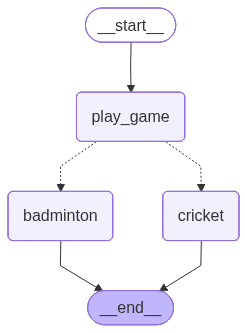

In [30]:
builder=StateGraph(TypedDictState)
builder.add_node('play_game', play_game)
builder.add_node('cricket', cricket)
builder.add_node('badminton', badminton)

builder.add_edge(START, 'play_game')
builder.add_conditional_edges('play_game', decide_play)
builder.add_edge('cricket', END)
builder.add_edge('badminton', END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [31]:
graph.invoke({'name': 'sandeep'})

-- play game node has been called --
-- badminton node has been called --


{'name': 'sandeep', 'game': 'badminton'}

In [32]:
graph.invoke({'name': 123})

-- play game node has been called --
-- cricket node has been called --


{'name': 123, 'game': 'cricket'}

In [33]:
### Data classes

# python's data classes provide another way to define structured data

from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal['cricket', 'badminton']

In [34]:
def play_game(state: DataClassState):
    print("-- play game node has been called --")
    return {"name": state.name + " want to play"}

def cricket(state: DataClassState):
    print("-- cricket node has been called --")
    return {"name": state.name + " cricket", "game": "cricket"}

def badminton(state: DataClassState):
    print("-- badminton node has been called --")
    return {"name": state.name + " badminton", "game": "badminton"}

def decide_play(state: DataClassState) -> Literal['cricket', 'badminton']:
    if random.random()<0.5:
        return 'cricket'
    else:
        return 'badminton'

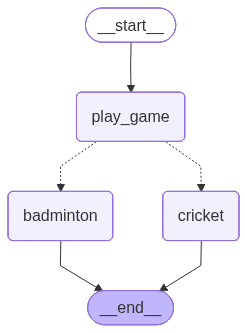

In [35]:
builder=StateGraph(DataClassState)
builder.add_node('play_game', play_game)
builder.add_node('cricket', cricket)
builder.add_node('badminton', badminton)

builder.add_edge(START, 'play_game')
builder.add_conditional_edges('play_game', decide_play)
builder.add_edge('cricket', END)
builder.add_edge('badminton', END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
graph.invoke(DataClassState(name='sandeep', game='badminton'))

-- play game node has been called --
-- cricket node has been called --


{'name': 'sandeep want to play cricket', 'game': 'cricket'}

In [37]:
graph.invoke(DataClassState(name='sandeep', game='cricket'))

-- play game node has been called --
-- cricket node has been called --


{'name': 'sandeep want to play cricket', 'game': 'cricket'}